In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity


In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")


PPLX_API_KEY:  ········


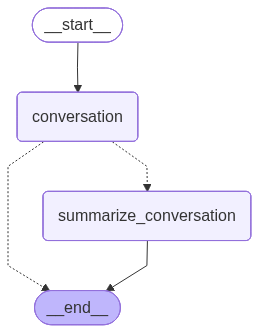

In [3]:
from IPython.display import Image, display
from typing import Literal
from typing_extensions import TypedDict

from langchain_perplexity import ChatPerplexity
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
    AIMessage,
    BaseMessage,
)
from langchain_core.runnables import RunnableConfig

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END, MessagesState

class State(MessagesState):
    summary: str

llm = ChatPerplexity(model="sonar-pro")

def call_model(state: State, config: RunnableConfig) -> State:
    messages: list[BaseMessage] = state.get("messages", [])
    summary = state.get("summary", "")

    if summary:
        system_msg = SystemMessage(
            content=f"Conversation summary so far: {summary}"
        )
        send_messages = [system_msg] + messages
    else:
        send_messages = messages

    response = llm.invoke(send_messages, config=config)
    return {
        "messages": messages + [response],
        "summary": summary,
    }

def summarize_conversation(state: State, config: RunnableConfig) -> State:
    summary = state.get("summary", "")
    messages: list[BaseMessage] = state.get("messages", [])

    if summary:
        prompt = (
            f"This is the current summary of the conversation: {summary}\n\n"
            "Update this summary to include the new messages above."
        )
    else:
        prompt = "Create a short summary of the conversation above."

    summary_messages = messages + [HumanMessage(content=prompt)]
    summary_response = llm.invoke(summary_messages, config=config)

    new_summary = summary_response.content
    return {
        "messages": [],
        "summary": new_summary,
    }

def should_continue(state: State) -> Literal["summarize_conversation", END]:
    messages = state.get("messages", [])
    if len(messages) > 6:
        return "summarize_conversation"
    return END

workflow = StateGraph(State)
workflow.add_node("conversation", call_model)
workflow.add_node("summarize_conversation", summarize_conversation)
workflow.add_edge(START, "conversation")
workflow.add_conditional_edges("conversation", should_continue)
workflow.add_edge("summarize_conversation", END)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "thread-1"}}

user_message = HumanMessage(
    content="Hello! Can you explain what a data pipeline is in simple terms?"
)

for chunk in graph.stream({"messages": [user_message]}, config=config, stream_mode="updates"):
    print("Update:", chunk)
    print("-" * 40)


Update: {'conversation': {'messages': [HumanMessage(content='Hello! Can you explain what a data pipeline is in simple terms?', additional_kwargs={}, response_metadata={}, id='a8c569f1-cd88-441e-ae9a-9ca2e4046f53'), AIMessage(content='Hello! Sure, I can explain what a data pipeline is in simple terms.\n\nA **data pipeline** is like a digital assembly line for data. It’s a system that automatically moves data from one place (like a website, app, or database) to another (like a data warehouse or analytics tool), often cleaning, organizing, or transforming it along the way.\n\nThink of it like a water pipeline: water flows from a source (like a river), gets cleaned and treated, and then is delivered to homes. In the same way, a data pipeline takes raw data, processes it (removes errors, combines it, or changes its format), and delivers it to where it’s needed—so people or systems can use it for reports, analysis, or decision-making.\n\nIn short:  \nA data pipeline **collects data, processe

In [5]:
config = {"configurable": {"thread_id": "thread-2"}}

user_message = HumanMessage(
    content="Describe the main steps involved in brewing a cup of coffee."
)

for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
    print("New state:")
    for m in event["messages"]:
        print(f"{m.type}: {m.content}")
    print("-" * 40)


New state:
human: Describe the main steps involved in brewing a cup of coffee.
----------------------------------------
New state:
human: Describe the main steps involved in brewing a cup of coffee.
ai: The main steps involved in brewing a cup of coffee are as follows:

1. **Roasting**: Coffee beans are roasted to develop their flavor. This is typically done before purchase, but it's the first step in the overall coffee preparation process.

2. **Grinding**: The roasted beans are ground to a consistency appropriate for the brewing method. The fineness of the grind affects the extraction and taste of the coffee. For example, drip coffee makers use a medium grind, espresso uses a fine grind, and French press uses a coarse grind.

3. **Measuring**: Use the correct ratio of coffee to water. A common starting point is about 1 to 2 tablespoons of ground coffee per 6 ounces of water, but this can be adjusted to taste.

4. **Heating Water**: Bring fresh, cold water to the right temperature. Fo

In [6]:
config = {"configurable": {"thread_id": "thread-3"}}

user_message = HumanMessage(
    content="Explain what a database index is, in one or two sentences."
)

for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
    for m in event["messages"]:
        m.pretty_print()
    print("---" * 25)


================================ Human Message =================================

Explain what a database index is, in one or two sentences.
---------------------------------------------------------------------------
================================ Human Message =================================

Explain what a database index is, in one or two sentences.
================================== Ai Message ==================================

A database index is a data structure that improves the speed of data retrieval operations on a table by providing quick access to specific rows, typically using pointers to their physical location. It works like a lookup table, allowing the database to find data without scanning every row, but requires extra storage and maintenance overhead.
---------------------------------------------------------------------------


In [7]:
import asyncio
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "thread-4"}}
user_message = HumanMessage(
    content="Give me a brief overview of how the internet works."
)

async def watch_events():
    async for event in graph.astream_events(
        {"messages": [user_message]},
        config=config,
        version="v2",
    ):
        print(
            f"Node: {event['metadata'].get('langgraph_node','')} | "
            f"Event: {event['event']} | Name: {event.get('name','')}"
        )

await watch_events()


Node:  | Event: on_chain_start | Name: LangGraph
Node: conversation | Event: on_chain_start | Name: conversation
Node: conversation | Event: on_chat_model_start | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Event: on_chat_model_stream | Name: ChatPerplexity
Node: conversation | Eve

In [8]:
import asyncio

node_to_stream = "conversation"
config = {"configurable": {"thread_id": "thread-5"}}
user_message = HumanMessage(
    content="Explain recursion in programming in a friendly way."
)

async def stream_tokens():
    async for event in graph.astream_events(
        {"messages": [user_message]},
        config=config,
        version="v2",
    ):
        if (
            event["event"] == "on_chat_model_stream"
            and event["metadata"].get("langgraph_node", "") == node_to_stream
        ):
            data = event["data"]
            chunk = data.get("chunk")
            if chunk:
                print(chunk.content, end="|")

await stream_tokens()
print()


Sure|! Let’s| make recursion super| friendly and easy to understand|.

Imagine you|’re standing in a long| line of people|, and you want to know| how many people are in front of| you. Instead of counting| everyone yourself, you ask| the person right| in front of you,| “How| many people are in front of| you?” That person then| asks the same| question to the person| in front of them,| and so on,| all the way until the first| person in line.| That first| person says, “There|’s no one in| front of me,” and tells| the next person,| “1.”| The next person says|, “2,” and so| on, until the answer| finally gets| back to you.

|That’s recursion| in programming!

### In| Simple Terms|:
- **Recursion**| is when a function calls| itself to solve a smaller part of the same| problem.
- It keeps breaking| the problem down into| smaller pieces until it| reaches a point| where the answer| is super simple| (this is called the| **base case**).
- Once| it hits that| simple case|, it starts building| the an

In [9]:
import asyncio

node_to_stream = "conversation"
config = {"configurable": {"thread_id": "thread-6"}}
user_message = HumanMessage(
    content="Describe in simple terms what an API is and why it is useful."
)

async def stream_tokens_again():
    async for event in graph.astream_events(
        {"messages": [user_message]},
        config=config,
        version="v2",
    ):
        if (
            event["event"] == "on_chat_model_stream"
            and event["metadata"].get("langgraph_node", "") == node_to_stream
        ):
            data = event["data"]
            chunk = data.get("chunk")
            if chunk:
                print(chunk.content, end="|")

await stream_tokens_again()
print()


An| **|API| (|Application| Programming| Interface|)**| is| a| set| of| rules| that| lets| different| software| programs| communicate| and| share| information| or| functionality| with| each| other||[1]|[3]|[5]|[6].| 

|AP|Is| act| as| a| **|bridge|**| or| **|middle|man|**| between| applications|,| so| developers| don|’t| have| to| build| everything| themselves|.| For| example|,| your| weather| app| uses| an| API| to| get| weather| data| from| a| weather| service|,| rather| than| storing| all| that| information| itself||[2]|[4].| This| saves| time| and| resources|,| encourages| innovation|,| and| makes| it| easier| to| add| new| features| or| connect| systems|[1]|[4]|[8].

|-| **|Simple| analogy|:**| Imagine| a| restaurant|.| You| (|the| customer|)| don|’t| go| into| the| kitchen| to| cook| your| meal|;| instead|,| you| tell| the| waiter| (|the| API|)| what| you| want|,| and| they| bring| it| from| the| kitchen| (|the| server|).| You| get| what| you| need| without| knowing| how| it|’s| p

In [10]:
print("LangGraph + Perplexity setup is ready for more streaming examples.")


LangGraph + Perplexity setup is ready for more streaming examples.


In [11]:
config = {"configurable": {"thread_id": "thread-7"}}
user_message = HumanMessage(
    content="List three healthy breakfast ideas."
)

for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
    print("Step:")
    event["messages"][-1].pretty_print()
    print("-" * 40)


Step:
================================ Human Message =================================

List three healthy breakfast ideas.
----------------------------------------
Step:
================================== Ai Message ==================================

Here are three healthy breakfast ideas:

1. **Avocado and Egg on Whole Grain Toast**  
   Toast a slice of whole grain bread, mash ¼ avocado on top, and add a cooked egg (poached or sunny side up is recommended). This combination provides fiber, healthy fats, and protein.

2. **Greek Yogurt with Berries, Nuts, and Seeds**  
   Mix Greek yogurt with a handful of fresh berries (like blueberries or strawberries), a sprinkle of nuts (such as almonds or walnuts), and a few seeds (like chia or flaxseed) for a high-protein, antioxidant-rich breakfast.

3. **Baked Oatmeal with Fruit**  
   Prepare baked oatmeal using oats, milk (or a dairy-free alternative), eggs, and your favorite fruits (such as apples, bananas, or blueberries). This dish is h

In [12]:
config = {"configurable": {"thread_id": "thread-8"}}
user_message = HumanMessage(
    content="Summarize the benefits of regular exercise in two sentences."
)

for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
    last = event["messages"][-1]
    print(f"{last.type}: {last.content}")
    print("-" * 40)


human: Summarize the benefits of regular exercise in two sentences.
----------------------------------------
ai: Regular exercise significantly reduces the risk of chronic diseases such as heart disease, stroke, type 2 diabetes, and certain cancers, while also strengthening muscles, bones, and the cardiovascular system. It boosts mental health by improving mood, reducing stress and anxiety, enhancing brain function, and increasing energy levels, leading to a healthier and happier life.
----------------------------------------


The streamed objects have: 

* `event`: Type
* `data`: State

In [13]:
config = {"configurable": {"thread_id": "thread-9"}}
user_message = HumanMessage(
    content="Explain what version control is, as if you are talking to a beginner."
)

for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
    print("Latest message:")
    event["messages"][-1].pretty_print()
    print("-" * 40)


Latest message:
================================ Human Message =================================

Explain what version control is, as if you are talking to a beginner.
----------------------------------------
Latest message:
================================== Ai Message ==================================

Version control is a system that helps you track and manage changes to files over time, particularly code.[9] Think of it like a detailed history book for your project—every time you make a change, it gets recorded with information about what changed, who made the change, and when it happened.

## Why You Need Version Control

Imagine working on a project and accidentally deleting important code, or making a change that breaks everything. Without version control, you'd be stuck. With it, you can **roll back to an earlier version** in seconds, undoing the mistake as if it never happened.[2] This acts as a safety net for your work.

Version control also makes **collaboration much easier

There are some new streaming mode that are only supported via the API.

For example, we can  [use `messages` mode](https://docs.langchain.com/oss/python/langgraph/streaming#supported-stream-modes) to better handle the above case!

This mode currently assumes that you have a `messages` key in your graph, which is a list of messages.

All events emitted using `messages` mode have two attributes:

* `event`: This is the name of the event
* `data`: This is data associated with the event

In [14]:
config = {"configurable": {"thread_id": "thread-10"}}
user_message = HumanMessage(
    content="What are three key skills for a data analyst?"
)

for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
    msgs = event["messages"]
    print(f"Total messages so far: {len(msgs)}")
    print("Last message:")
    msgs[-1].pretty_print()
    print("-" * 40)


Total messages so far: 1
Last message:
================================ Human Message =================================

What are three key skills for a data analyst?
----------------------------------------
Total messages so far: 2
Last message:
================================== Ai Message ==================================

Based on the search results, three key skills for a data analyst are:

1. **SQL (Structured Query Language):** This is consistently highlighted as the most important technical skill for data analysts. It allows them to efficiently query, manage, and manipulate large datasets across various systems.

2. **Statistical Analysis:** A strong foundation in statistics and analytics is essential for interpreting data, identifying trends, making inferences, and ensuring accurate, trustworthy results.

3. **Data Visualization:** The ability to present data clearly and effectively using visualization tools helps analysts communicate insights to both technical and non-techni

In [ ]:
config = {"configurable": {"thread_id": "thread-11"}}

questions = [
    "Hi! I want to learn about machine learning.",
    "What is supervised learning?",
    "What is unsupervised learning?",
    "Can you give a real-world example?",
]

for text in questions:
    user_message = HumanMessage(content=text)
    last_msg = None
    for event in graph.stream({"messages": [user_message]}, config=config, stream_mode="values"):
        last_msg = event["messages"][-1]
    print("Latest assistant reply:")
    last_msg.pretty_print()
    print("-" * 40)

print("If the conversation grows long enough, the graph will summarize automatically.")
